In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [19]:
%%time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

CPU times: user 71 µs, sys: 0 ns, total: 71 µs
Wall time: 76.8 µs


In [20]:
%%time
df = pd.read_csv("TwitterHate.csv")
df.head()

CPU times: user 72.7 ms, sys: 14.9 ms, total: 87.6 ms
Wall time: 88.7 ms


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [24]:
%%time
texts = df['tweet'].fillna("").astype(str)
labels = df['label']

# Encode labels
le = LabelEncoder()
labels = le.fit_transform(labels)

# Tokenization
max_words = 20000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Padding
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)

y = labels

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

CPU times: user 1.63 s, sys: 27.6 ms, total: 1.66 s
Wall time: 1.68 s


In [22]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

**RNN MODEL**

In [25]:
model_rnn = Sequential()
model_rnn.add(Embedding(max_words, 128))
model_rnn.add(SimpleRNN(64))
model_rnn.add(Dense(3, activation='softmax'))

model_rnn.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_rnn = model_rnn.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.9341 - loss: 0.2193 - val_accuracy: 0.9566 - val_loss: 0.1282
Epoch 2/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9805 - loss: 0.0587 - val_accuracy: 0.9558 - val_loss: 0.1408
Epoch 3/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 24s 75ms/step - accuracy: 0.9977 - loss: 0.0091 - val_accuracy: 0.9458 - val_loss: 0.1722


In [26]:
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test)
print("RNN Accuracy:", acc_rnn)

200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9432 - loss: 0.2028
RNN Accuracy: 0.9432191252708435


**LSTM MODEL**

In [27]:
model_lstm = Sequential()
model_lstm.add(Embedding(max_words, 128))
model_lstm.add(LSTM(64))
model_lstm.add(Dense(3, activation='softmax'))

model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(X_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

Epoch 1/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 67s 198ms/step - accuracy: 0.9391 - loss: 0.2060 - val_accuracy: 0.9623 - val_loss: 0.1145
Epoch 2/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 53s 166ms/step - accuracy: 0.9751 - loss: 0.0733 - val_accuracy: 0.9671 - val_loss: 0.1113
Epoch 3/3
320/320 ━━━━━━━━━━━━━━━━━━━━ 68s 214ms/step - accuracy: 0.9885 - loss: 0.0368 - val_accuracy: 0.9644 - val_loss: 0.1244


In [28]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test)
print("LSTM Accuracy:", acc_lstm)

200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9540 - loss: 0.1556
LSTM Accuracy: 0.9540122151374817


**Comparison B/W RNN and LSTM**

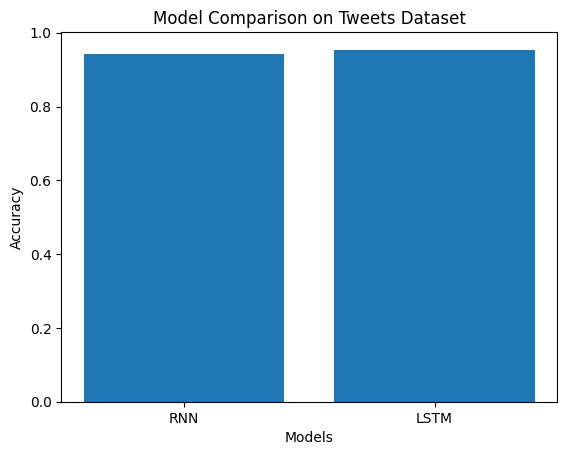

In [29]:
models = ['RNN', 'LSTM']
accuracies = [acc_rnn, acc_lstm]

plt.bar(models, accuracies)
plt.title("Model Comparison on Tweets Dataset")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

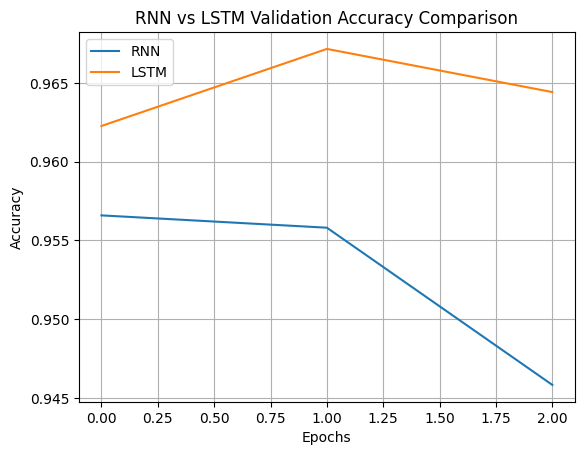

In [30]:
# RNN vs LSTM Accuracy Comparison (Epoch-wise)

plt.plot(history_rnn.history['val_accuracy'], label='RNN')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM')

plt.title("RNN vs LSTM Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()